# AirSense: AQI & Public Health Business Intelligence

**Author:** Sagar  
**Summary:** This notebook cleans Indian air-quality data, develops decision-oriented KPIs, trains a prediction model, and exports tables for the dashboard. Place the source file at `data/raw/city_day.csv`.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
PROJECT_ROOT = Path.cwd().resolve().parent
if not (PROJECT_ROOT / 'data').exists(): PROJECT_ROOT = Path.cwd().resolve()
RAW_PATH = PROJECT_ROOT / 'data' / 'raw' / 'city_day.csv'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print(f'Expected raw file: {RAW_PATH}')

Expected raw file: D:\GitHub\Saar_AirSense.ipynb\data\raw\city_day.csv


## Load and audit

In [2]:
if not RAW_PATH.exists():
    raise FileNotFoundError(f'Raw dataset not found at {RAW_PATH}. Download city_day.csv from data/DATA_SOURCE.md and place it there.')
raw_df = pd.read_csv(RAW_PATH)
print(f'Rows: {len(raw_df):,} | Columns: {len(raw_df.columns)}')
display(raw_df.head())

Rows: 29,531 | Columns: 16


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [3]:
df = raw_df.copy()
df.columns = df.columns.str.strip().str.lower().str.replace(r'[^a-z0-9]+', '_', regex=True).str.strip('_')
required = {'city', 'date', 'aqi'}
missing = required.difference(df.columns)
if missing: raise ValueError(f'Missing required columns: {sorted(missing)}')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['city'] = df['city'].astype('string').str.strip().str.replace(r'\s+', ' ', regex=True)
numeric_columns = [c for c in ['aqi','pm2_5','pm10','no','no2','nox','nh3','so2','co','o3','benzene','toluene','xylene'] if c in df.columns]
for column in numeric_columns: df[column] = pd.to_numeric(df[column], errors='coerce')
audit = pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing_count': df.isna().sum(), 'missing_pct': (df.isna().mean() * 100).round(2)})
print(f'Duplicates: {df.duplicated().sum():,} | Invalid dates: {df.date.isna().sum():,}')
display(audit)

# Pollutant gaps are median-filled using the observed city distribution; key identity/AQI rows are dropped.
pollutant_columns = [c for c in numeric_columns if c != 'aqi']
for column in pollutant_columns:
    df[column] = df[column].fillna(df[column].median())
df = df.drop_duplicates().dropna(subset=['city','date','aqi']).copy()
df = df[df.aqi >= 0].copy()
print(f'Rows after cleaning: {len(df):,}')
print(f'Remaining pollutant nulls: {int(df[pollutant_columns].isna().sum().sum())}')

Duplicates: 0 | Invalid dates: 0


,dtype,missing_count,missing_pct
city,string,0,0.00
date,datetime64[us],0,0.00
pm2_5,float64,4598,15.57
pm10,float64,11140,37.72
no,float64,3582,12.13
no2,float64,3585,12.14
nox,float64,4185,14.17
nh3,float64,10328,34.97
co,float64,2059,6.97
so2,float64,3854,13.05


Rows after cleaning: 24,850
Remaining pollutant nulls: 0


## 4. Cleaning decisions and derived fields

Pollutant missing values are filled with the median of each pollutant in the available dataset. This keeps daily city observations available for trend analysis without inventing extreme values. Rows missing `City`, `Date`, or `AQI` are removed because those fields are required for the KPIs. AQI categories use the standard CPCB-style breakpoints below.

In [4]:
def aqi_category(aqi):
    if aqi <= 50: return 'Good'
    if aqi <= 100: return 'Satisfactory'
    if aqi <= 200: return 'Moderate'
    if aqi <= 300: return 'Poor'
    if aqi <= 400: return 'Very Poor'
    return 'Severe'

df['year'] = df.date.dt.year
df['month'] = df.date.dt.month
df['month_name'] = df.date.dt.month_name().str[:3]
df['season'] = df.month.map({12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Summer',6:'Summer',7:'Monsoon',8:'Monsoon',9:'Monsoon',10:'Post-monsoon',11:'Post-monsoon'})
df['aqi_category'] = df.aqi.map(aqi_category)
display(df.head())

,city,date,pm2_5,pm10,no,no2,nox,nh3,co,so2,...,benzene,toluene,xylene,aqi,aqi_bucket,year,month,month_name,season,aqi_category
28,Ahmedabad,2015-01-29,83.13,95.68,6.93,28.71,33.72,15.85,6.93,49.52,...,0.02,0.00,3.14,209.0,Poor,2015,1,Jan,Winter,Poor
29,Ahmedabad,2015-01-30,79.84,95.68,13.85,28.68,41.08,15.85,13.85,48.49,...,0.04,0.00,4.81,328.0,Very Poor,2015,1,Jan,Winter,Very Poor
30,Ahmedabad,2015-01-31,94.52,95.68,24.39,32.66,52.61,15.85,24.39,67.39,...,0.24,0.01,7.67,514.0,Severe,2015,1,Jan,Winter,Severe
31,Ahmedabad,2015-02-01,135.99,95.68,43.48,42.08,84.57,15.85,43.48,75.23,...,0.40,0.04,25.87,782.0,Severe,2015,2,Feb,Winter,Severe
32,Ahmedabad,2015-02-02,178.33,95.68,54.56,35.31,72.80,15.85,54.56,55.04,...,0.46,0.06,35.61,914.0,Severe,2015,2,Feb,Winter,Severe


## EDA and KPI layer

In [5]:
monthly_trend = df.assign(month_start=df.date.dt.to_period('M').dt.to_timestamp()).groupby('month_start', as_index=False).aqi.mean()
city_average = df.groupby('city', as_index=False).agg(average_aqi=('aqi', 'mean'), observed_days=('aqi', 'count'))
city_severity = df.assign(poor_or_worse=df.aqi >= 201).groupby('city', as_index=False).agg(poor_or_worse_days=('poor_or_worse', 'sum'))
city_risk = city_average.merge(city_severity, on='city')
city_risk['poor_or_worse_pct'] = (city_risk['poor_or_worse_days'] / city_risk['observed_days'] * 100).round(2)
city_risk = city_risk.sort_values(['poor_or_worse_pct', 'average_aqi'], ascending=False)
pollutant_columns = [c for c in ['pm2_5', 'pm10', 'no2', 'so2', 'co', 'o3'] if c in df.columns]
pollutant_means = df[pollutant_columns].mean().sort_values(ascending=False).rename('mean_value').reset_index().rename(columns={'index': 'pollutant'})
dominant_pollutant = df.groupby('city')[pollutant_columns].mean().idxmax(axis=1).rename('dominant_pollutant').reset_index()
city_risk = city_risk.merge(dominant_pollutant, on='city')
display(city_risk.head(10)); display(pollutant_means)

,city,average_aqi,observed_days,poor_or_worse_days,poor_or_worse_pct,dominant_pollutant
0,Ahmedabad,452.122939,1334,1092,81.86,pm10
1,Delhi,259.487744,1999,1301,65.08,pm10
2,Patna,240.782042,1459,781,53.53,pm2_5
3,Gurugram,225.123882,1453,753,51.82,pm10
4,Lucknow,217.973059,1893,935,49.39,pm2_5
5,Talcher,172.886819,698,205,29.37,pm10
6,Guwahati,140.111111,495,133,26.87,pm10
7,Kolkata,140.566313,754,198,26.26,pm10
8,Jorapokhar,159.251621,771,173,22.44,pm10
9,Brajrajnagar,150.280505,713,156,21.88,pm10


,pollutant,mean_value
0,pm10,111.960285
1,pm2_5,66.960771
2,o3,34.780619
3,no2,28.863712
4,so2,14.236262
5,co,2.319207


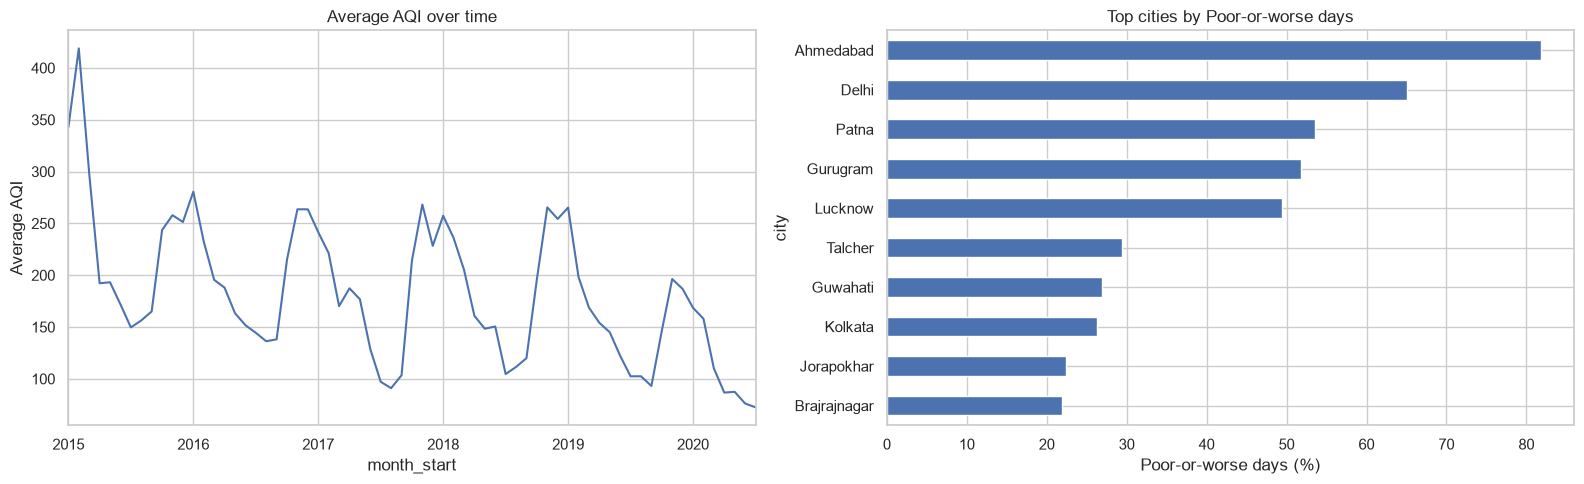

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
monthly_trend.plot(x='month_start', y='aqi', ax=axes[0], title='Average AQI over time', legend=False)
city_risk.head(10).sort_values('poor_or_worse_pct').plot.barh(x='city', y='poor_or_worse_pct', ax=axes[1], title='Top cities by Poor-or-worse days', legend=False)
axes[0].set_ylabel('Average AQI'); axes[1].set_xlabel('Poor-or-worse days (%)'); plt.tight_layout(); plt.show()

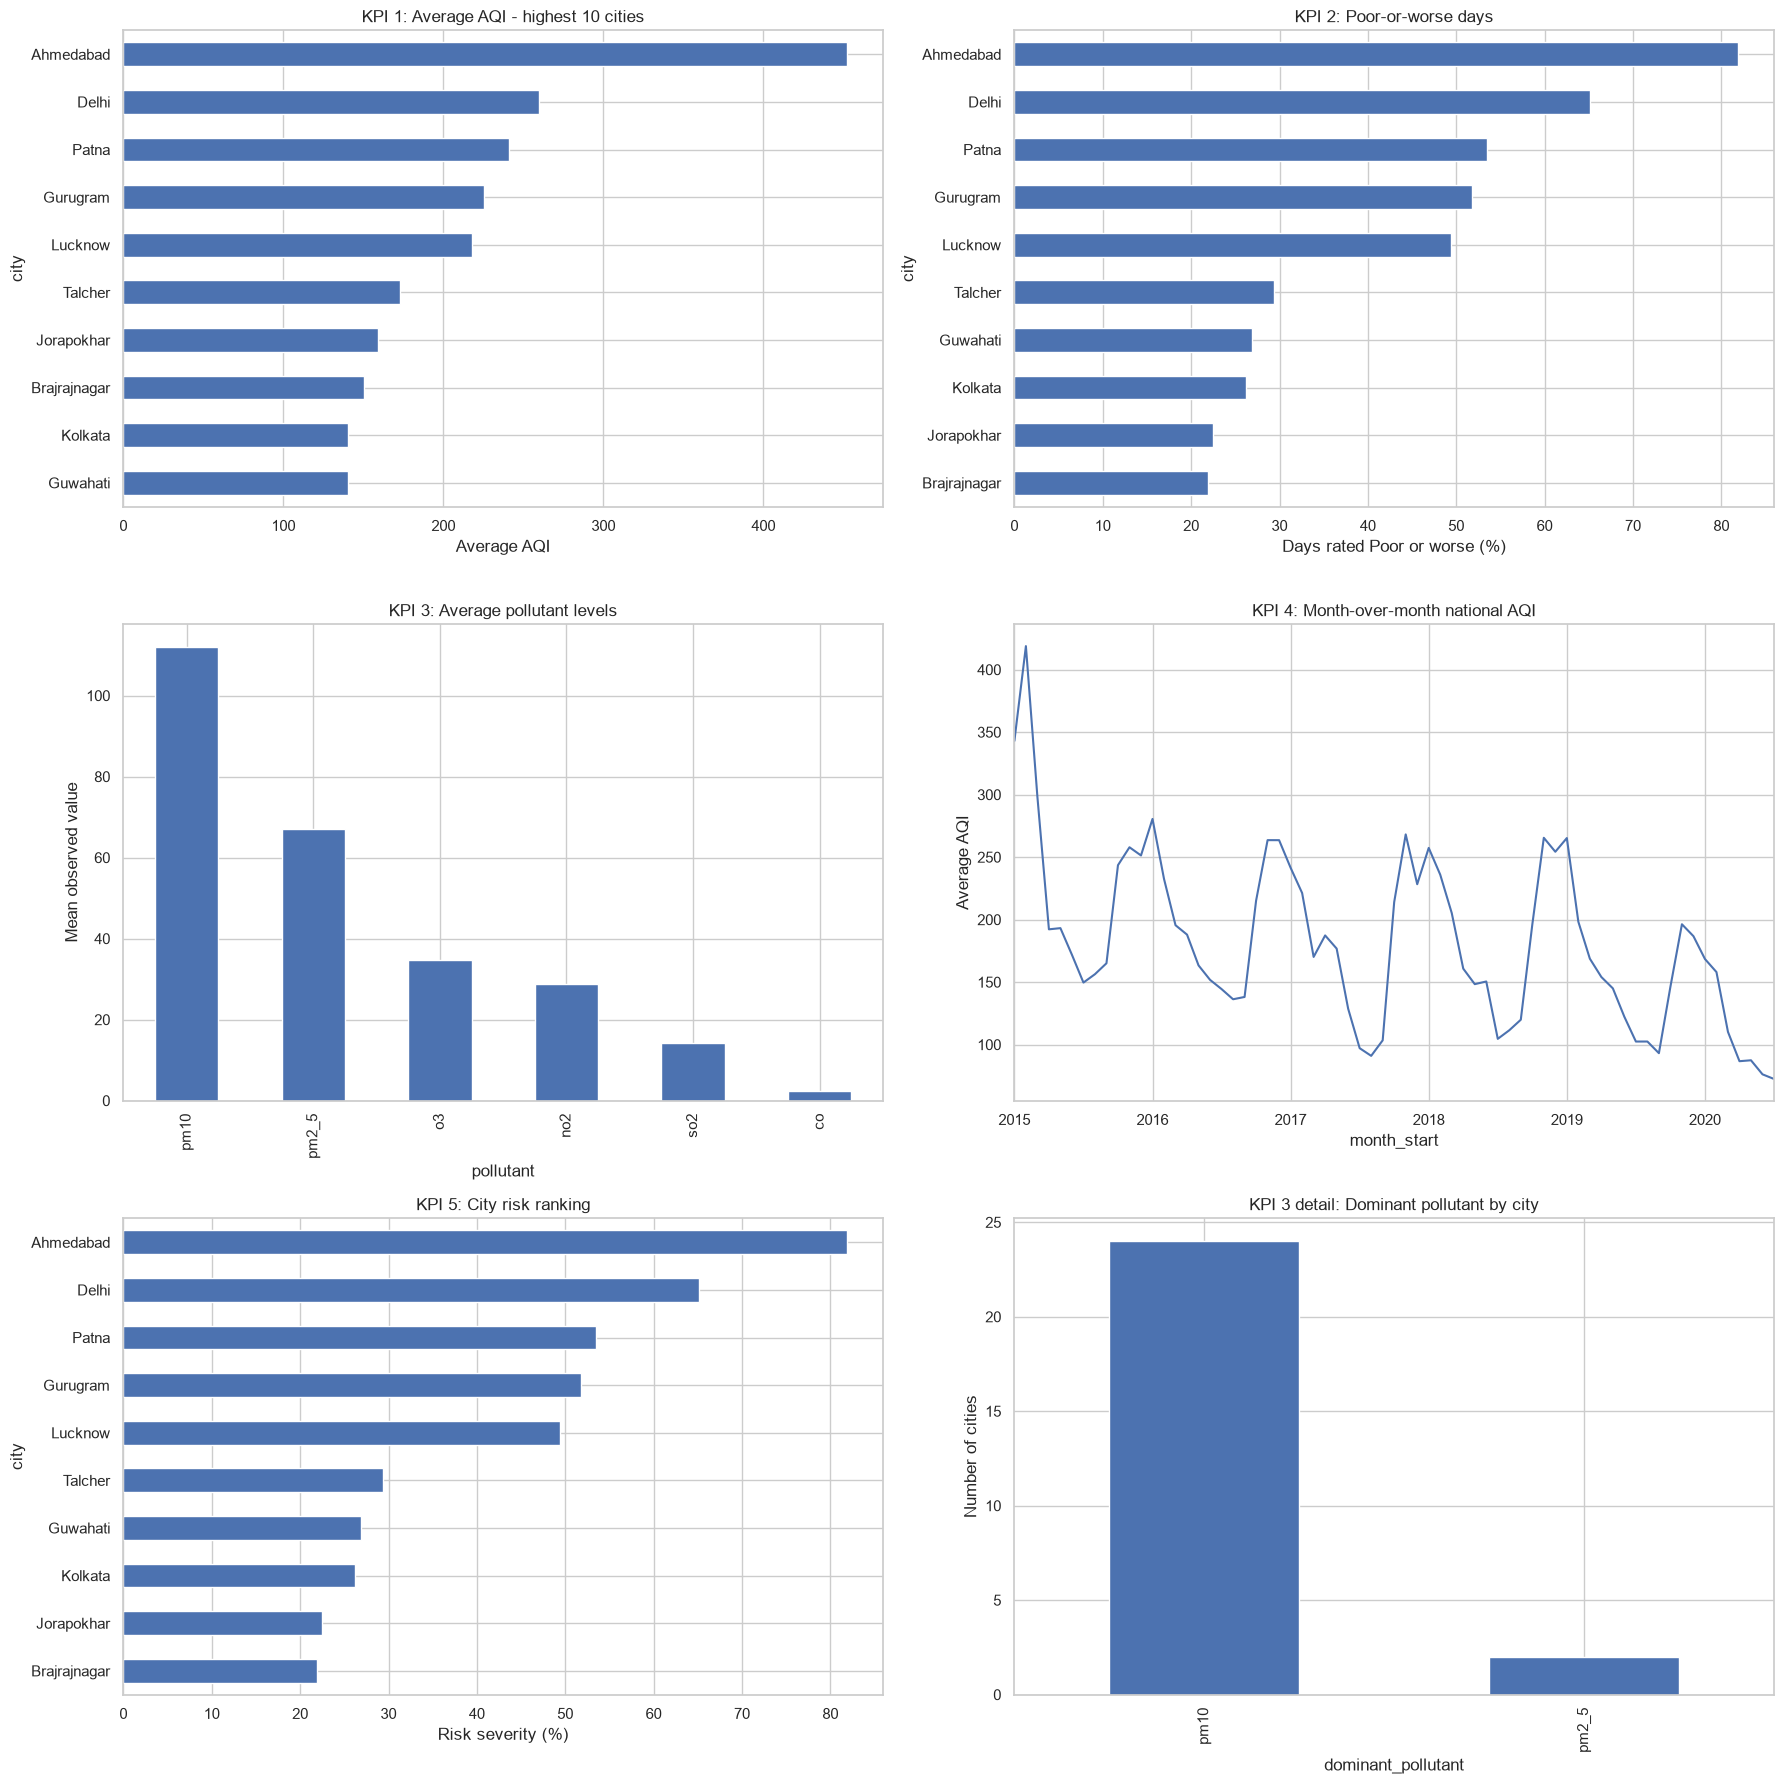

In [7]:
# Five core KPI charts
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

city_average.sort_values('average_aqi').tail(10).plot.barh(x='city', y='average_aqi', ax=axes[0, 0], legend=False, title='KPI 1: Average AQI - highest 10 cities')
axes[0, 0].set_xlabel('Average AQI')

city_risk.sort_values('poor_or_worse_pct').tail(10).plot.barh(x='city', y='poor_or_worse_pct', ax=axes[0, 1], legend=False, title='KPI 2: Poor-or-worse days')
axes[0, 1].set_xlabel('Days rated Poor or worse (%)')

pollutant_means.plot.bar(x='pollutant', y='mean_value', ax=axes[1, 0], legend=False, title='KPI 3: Average pollutant levels')
axes[1, 0].set_ylabel('Mean observed value')

monthly_trend.plot(x='month_start', y='aqi', ax=axes[1, 1], legend=False, title='KPI 4: Month-over-month national AQI')
axes[1, 1].set_ylabel('Average AQI')

city_risk.head(10).sort_values('poor_or_worse_pct').plot.barh(x='city', y='poor_or_worse_pct', ax=axes[2, 0], legend=False, title='KPI 5: City risk ranking')
axes[2, 0].set_xlabel('Risk severity (%)')

city_risk['dominant_pollutant'].value_counts().plot.bar(ax=axes[2, 1], title='KPI 3 detail: Dominant pollutant by city')
axes[2, 1].set_ylabel('Number of cities')
plt.tight_layout()
plt.show()

### KPI narratives

**KPI 1 - Average AQI**
- **Fact:** The chart ranks the ten cities with the highest observed average AQI.
- **Driver:** Compare the dominant pollutant table with these cities to identify the strongest measured pollutant association.
- **Risk:** Cities at the top of the ranking experience the greatest average exposure in this dataset.
- **Opportunity:** Prioritize monitoring and source-specific interventions in the highest-AQI cities.
- **Action:** Use the top-ranked city and its dominant pollutant to define a targeted seasonal mitigation plan.

**KPI 2 - Poor-or-worse days**
- **Fact:** The chart shows the percentage of observed days with AQI at or above 201 for each city.
- **Driver:** Seasonal concentration patterns and pollutant levels should be checked against the monthly trend.
- **Risk:** A high severity percentage indicates recurring rather than isolated exposure.
- **Opportunity:** Focus public advisories and mitigation resources where severity is most frequent.
- **Action:** Issue city-specific alerts during the months in which the trend is highest.

**KPI 3 - Dominant pollutant**
- **Fact:** The pollutant charts compare mean pollutant levels and the highest mean pollutant for each city.
- **Driver:** The dominant pollutant is an evidence-based starting point for source investigation, not proof of causation.
- **Risk:** Cities with a consistent dominant pollutant may require pollutant-specific health guidance.
- **Opportunity:** Match monitoring and control programs to the pollutant profile.
- **Action:** Review the leading pollutant by city before selecting an intervention.

**KPI 4 - Month-over-month trend**
- **Fact:** The line chart shows national average AQI by month.
- **Driver:** Peaks reveal when seasonal conditions coincide with higher observed AQI.
- **Risk:** Repeated peaks create predictable periods of elevated public-health exposure.
- **Opportunity:** Prepare interventions and communications before peak months.
- **Action:** Schedule pre-season inspections and advisories ahead of the highest-AQI period.

**KPI 5 - City risk ranking**
- **Fact:** The ranking orders cities by the percentage of observed Poor-or-worse AQI days.
- **Driver:** Compare ranking with average AQI, dominant pollutant, and season to form a city profile.
- **Risk:** The highest-ranked cities should receive the earliest attention in a constrained response program.
- **Opportunity:** Use the ranking to prioritize resources transparently.
- **Action:** Select the top three cities for deeper drill-down and measurable mitigation targets.

## Fact / Driver / Risk / Opportunity / Action

Use the tables above to write evidence-based narratives for the report. For each KPI, state the measured **Fact**, supported **Driver**, exposed **Risk**, intervention **Opportunity**, and concrete **Action**.

In [8]:
df.to_csv(PROCESSED_DIR / 'aqi_clean.csv', index=False)
monthly_trend.to_csv(PROCESSED_DIR / 'monthly_aqi_trend.csv', index=False)
city_risk.to_csv(PROCESSED_DIR / 'city_risk_ranking.csv', index=False)
pollutant_means.to_csv(PROCESSED_DIR / 'pollutant_summary.csv', index=False)
print(f'Exported cleaned data and KPI tables to {PROCESSED_DIR}')

Exported cleaned data and KPI tables to D:\GitHub\Saar_AirSense.ipynb\data\processed


## Limitations

This analysis describes associations in monitoring data and does not establish causality. Missing observations, city coverage differences, station aggregation, and AQI threshold conventions should be disclosed in the final report. Forecasting is optional and should only be added after this descriptive analysis runs reproducibly.

## Prediction Model

A RandomForestRegressor predicts AQI from pollutant levels, city, and month.

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

feature_cols = [c for c in ['pm2_5','pm10','no2','so2','co','o3','month'] if c in df.columns]
model_df = df.dropna(subset=['aqi'] + feature_cols).copy()
X = model_df[feature_cols].copy()
X = pd.concat([X, pd.get_dummies(model_df['city'], prefix='city', drop_first=True)], axis=1)
y = model_df['aqi']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

MAE: 20.87
RMSE: 40.97


**Model summary:** RandomForestRegressor trained on pollutant levels, month, and city to predict AQI. MAE and RMSE are printed above. Limitations: this is an association-based model on historical data, not a causal or operational forecasting system. Performance varies by city and season.